In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
linarg_stats = pd.read_csv('../../data/ukb20279_linarg_stats.tsv', sep='\t')
vcf_pgen_stats = pd.read_csv('../../data/ukb20279_vcf_pgen_sizes.tsv', sep='\t')
df = pd.read_csv('../../data/ukb20279_grg_xsi_scipy_size_benchmark.tsv', sep='\t')

df['linear_arg_disk_size'] = [linarg_stats[(linarg_stats.linarg=='ukb20279_chr1-22') & (linarg_stats.chrom==chrom)].linarg_disk_size.iloc[0] for chrom in [1, 11, 21]]
df['pgen_disk_size'] = [vcf_pgen_stats[(vcf_pgen_stats.dataset=='all') & (vcf_pgen_stats.chrom==chrom)].pgen_size.iloc[0] for chrom in [1, 11, 21]]
df['vcf_disk_size'] = [vcf_pgen_stats[(vcf_pgen_stats.dataset=='all') & (vcf_pgen_stats.chrom==chrom)].vcf_size.iloc[0] for chrom in [1, 11, 21]]

disk_size = df.sum(axis=0)[1:][::-1]
df

,Unnamed: 0,chr,grg_disk_size,xsi_disk_size,grg_size_in_memory,scipy_size_in_memory,linear_arg_disk_size,pgen_disk_size,vcf_disk_size
0,0,1,4.990419,6.212586,10.867741,261.250998,2.071794,30.678073,186.308469
1,1,11,3.378318,3.837585,7.586984,168.791739,1.274212,19.643532,116.725648
2,2,21,0.950710,1.078546,2.146845,47.427527,0.391320,5.497758,30.694268


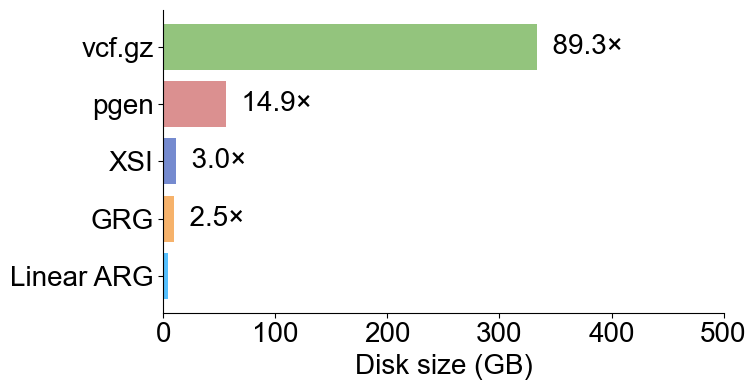

In [3]:
methods = [
    'vcf_disk_size',
    'pgen_disk_size',
    'xsi_disk_size',
    'grg_disk_size',
    'linear_arg_disk_size'
]

name = {
    'vcf_disk_size': 'vcf.gz',
    'pgen_disk_size': 'pgen',
    'xsi_disk_size': 'XSI',
    'grg_disk_size': 'GRG',
    'linear_arg_disk_size': 'Linear ARG'
    
}

plt.rcParams['font.family'] = 'Arial'
y = np.arange(len(methods))
colors = ['#93c47d', '#db9090', '#758acfff', '#f6b26b', '#56C1FF']

fig, ax = plt.subplots(figsize=(8, 4))
for i, method in enumerate(methods):
    ax.barh(y[i], disk_size[method], color=colors[i], label='Disk size (GB)' if i == 0 else "")
ax.set_yticks(y)
ax.set_yticklabels([name[m] for m in methods], fontsize=20)
ax.invert_yaxis()
ax.set_xlabel('Disk size (GB)', fontsize=20)
linarg_size = disk_size['linear_arg_disk_size']
for i, method in enumerate(methods):  # Only for scipy and grg
    if method == 'linear_arg_disk_size':
        continue
    speedup = disk_size[method] / linarg_size
    ax.text(disk_size[method] + 0.05, y[i], f"  {speedup:.1f}×", va='center', fontsize=20)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.tick_params(labelsize=20)
plt.tight_layout()
plt.xlim(0, 500)
plt.show()

In [4]:
disk_size

vcf_disk_size           333.728386
pgen_disk_size           55.819362
linear_arg_disk_size      3.737326
scipy_size_in_memory    477.470264
grg_size_in_memory       20.601569
xsi_disk_size            11.128717
grg_disk_size             9.319446
chr                      33.000000
dtype: float64